In [60]:
import sys
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import numpy as np
sys.path.append('../')
sys.path.append('../modules')
from Class_sem2dpack import *
from Stage_module import *
plt.rcParams['figure.dpi'] = 200

direct1 = '../../../../OUTPUT/Prenolin_PSV_Non_Linear'
is_overburden = False
fmin, fmax = 0.01, 10.0
SEM = sem2dpack(direct1)

Reading grid information...
Reading header file...
0.00019999999 50001 5
Extra station number:  5
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

1000
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
1230
1240
1250
1260
1270
1280
1290
1300
1310
1320
1330
1340
1350
1360
1370
1380
1390
1400
1410
1420
1430
1440
1450
1460
1470
1480
1490
1500
1510
1520
1530
1540
1550
1560
1570
1580
1590
1600
1610
1620
1630
1640
1650
1660
1670
1680
1690
1700
1710
1720
1730
1740
1750
1760
1770
1780
1790
1800
1810
1820
1830
1840
1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990
2000
2010
2020
2030
2040
2050
2060
2070
2080
2090
2100
2110
2120
2130
2140
2150
2160
2170
2180
2190
2200
2210
2220
2230
2240
2250
2260
2270
2280
2290
2300
2310
2320
2330
2340
2350
2360
2370
2380
2390
2400
2410
2420
2430
2440
2450
2460
2470
2480
2490
2500
2510
2520
2530
2540
2550
2560
2570
2580
2590
2600
2610
2620
2630
2640
2650
2660
2670
2680
2690
2700
2710
2720
2730
2740
2750
2760
2770
2780
2790
2800
2810
2820
2830
2840
2850
2860
2870
2880
2890
2900
2910
2920
2930
2940
2950
2960
2970
2980


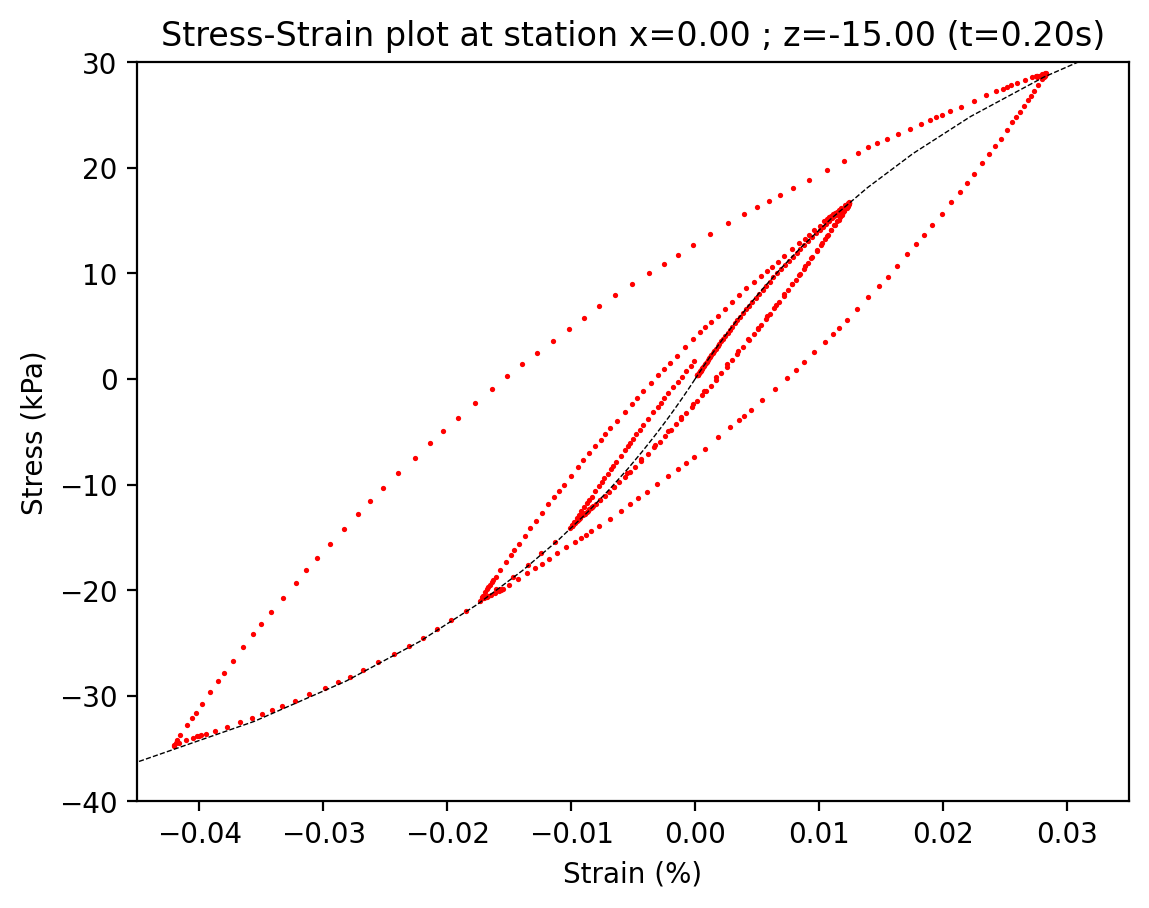

In [64]:
SEM.read_stress_strain()
Sigma = SEM.stress
Epsilon = SEM.strain
X_EXTRA = SEM.extra_coord[:,0]
Z_EXTRA = SEM.extra_coord[:,1]  

x_target = 0
z_target = -15
s = get_nearest_station(x_target, z_target, X_EXTRA, Z_EXTRA)

# gamma, tau, __ = compute_backbone_curve(gref=0.000365, mu=2000*300*300, Nspr=50)
# gamma *= 1e2
# tau /= 1e3
# plt.plot(Epsilon[:,s]*1e2,Sigma[:,s]/1e3)
# plt.plot(gamma,tau)
# plt.xlim(-0.03, 0.03)
# plt.ylim(-30, 30)
# plt.xlabel('Strain (%)')
# plt.ylabel('Stress (kPa)')

def compute_backbone_curve(gref=0.0, mu=0.0, Nspr=10):
   
    x0 = -6e0
    xu = np.log10(0.1e0)
    dx = (xu-x0)/(Nspr-1)

    gamma  = np.zeros(Nspr)
    G  = np.zeros(Nspr)
    R  = np.zeros(Nspr)

    for i in np.arange(Nspr-1)+1:
        gamma[i] = 10.0**(x0+ dx*(i-1))
        G[i] = 1.0/ (1.0+ abs(gamma[i]/ gref))
        R[i] = G[i]* mu* gamma[i]
    return gamma, R, G

gamma, tau, __ = compute_backbone_curve(gref=0.000365, mu=2000*300*300, Nspr=50)
gamma *= 1e2
tau /= 1e3
plt.plot(gamma,tau, ls='--', c='black', lw=0.5)
plt.plot(-gamma,-tau, ls='--', c='black', lw=0.5)
plt.xlim(-0.045, 0.035)
plt.ylim(-40, 30)

def animate(t):
    print(t)
    plt.scatter(Epsilon[t,s]*1e2,Sigma[t,s]/1e3, c='red',s=0.8)
    #plt.xlim(-0.03, 0.03)
    #plt.ylim(-30, 30)
    plt.xlabel('Strain (%)')
    plt.ylabel('Stress (kPa)')
    plt.title(f'Stress-Strain plot at station x={X_EXTRA[s]:.2f} ; z={Z_EXTRA[s]:.2f} (t={t*(20*1e-5):.2f}s)')

writer = anim.PillowWriter(fps=10)
animation = anim.FuncAnimation(plt.gcf(),animate,range(1000,6000,10))
animation.save('./Test.gif', writer)
